# 02 Object Detection

## Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import cv2
from ultralytics import YOLO
import os

## Object Detection Basics

### Bounding Boxes

We mentioned in our previous notebook that **bounding boxes** are used to denote where an object is located in a frame. 

We use bounding boxes in particular for a variety of reasons: 
- Precise Spatial Location: where in the frame the object is located
- Object Tracking: instead of tracking an object, which may move/blur, the bounding box is consistent
- Boundary + Size: We get a pretty good estimate of the size and boundaries of the object
- Computational Efficiency: Computing a box is much faster and cheaper than computing an object with various edges, colors, etc.
- Distinguishing Objects: Helps our model clearly identify objects (remember they cannot "see" like we can)

Typically, a bounding box will include $(x, y)$ coordinates and a height/width.

Let's see what a bounding box can look like: 

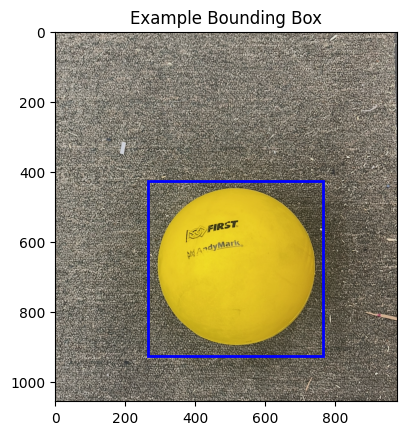

In [64]:
# read in ball image 
ball_bgr = cv2.imread('./ref_imgs/yellow_ball.png', cv2.IMREAD_COLOR)
ball = cv2.cvtColor(ball_bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots()
ax.imshow(ball)

# draw bounding box
box = Rectangle((265,425),500,500,fill=False,linewidth=2, color = 'blue')
ax.add_patch(box)

ax.set_title("Example Bounding Box")
plt.show()

### Metrics

#### Bounding Box Comparison

In our previous Regression and Classification examples, we had "true" values that served as our point of comparison for our predictions. For example, in the AP Calculus example, we had our true relationship between hours studied and exam scores. For CIFAR-10, we had the true labels that identified what the objects in the images were. 

These are known as **ground-truths**, and are *crucial* in ensuring we have a strong ability to perform evaluatoin. If we don't have confidence in our true values, we cannot perform evaluation! 

For object detection, we create our ground-truths by drawing bounding boxes that we feel best represent our objects. You want to draw the box as close to the boundaries of the object as possible, to remove any pixels that could distract from detecting the true object. 

Naturally, this is difficult depending on the shape of the object! That is why softwares like Roboflow include more advanced techniques to help you draw these boxes. 

Therefore, the way we analyze our predictions is by determining how "close" our predicted bounding box is to the ground-truth bounding box. 

#### Set Theory

We're not going to go in-depth into **set theory**, which is the study of **sets**, or unordered collections of distinct objects (elements). But, some intro is necessary to understand our metrics. 

Suppose we have two sets $A, B$. The set that consists of all elements exclusively in both $A$ and $B$ is known as the **intersection**, and is denoted as $A \cap B$. The set that consists of all elements in either $A$ or $B$ is known as the **union**, and is denoted as $A \cup B$. 

To illustrate this example, suppose we have the following sets: 

$A = (3, 5, 9, 12)$ <br>
$B = (9, 7, 5, 8, 1)$

Sets don't have to be the same length, or in the same order (which won't usually happen because sets are unordered). So let's look at what Intersection/Union looks like: 

Intersection: $A \cap B = (5, 9)$ <br>
Union: $A \cup B = (3, 9, 7, 5, 12, 8, 1)$

This logic also extends over to shapes, where can observe "elements" as areas, denoted within $| |$. We look at the following visualization to see how this logic extends out: 

![](./ref_imgs/union_intersection.png)

#### Intersection over Union (IoU) 

**Intersection over Union**, or **IoU**, is one of the more popular metrics for measuring how well our predicted bounding box matches the ground-truth bounding box. The formula is as follows: 

$IoU = \frac{|P \cap T|}{|P \cup T|}$

Where $P$ is our predicted bounding box, $T$ is our ground-truth bounding box, $\cap$ is the intersection, $\cup$ is the union, and the $| |$ represents the area of the intersection/union. So, IoU is the ratio of the areas of the intersection of our two boxes and the union. 

Intuitively, this formula should make sense as a good indicator of the correctness of our predicted bounding box. The union of the two areas represents any area that either of the boxes take up, whereas intersection is only where both take up. So, if our predicted box perfectly matches up with the ground truth box, we get a ratio of 1, as the union and the intersection are the same set! As the prediction becomes less accurate, our metric approaches 0, which would mean there is no overlap in our predicted boxes. 

Since our metric goes from 0 to 1, its also easy to quantify how good of a prediction any value in between is - a value of 0.5 is definitively indicative of a worse predictor than a value of 0.7. Typically, we want to see 0.7-0.9 as our value. 

Let's look at this with our ball example, using a fictional predicted bounding box: 

In [101]:
def calculate_iou(ground_truth, prediction): # we write our own IoU function 
    ''' Calculates the IoU of two bounding boxes
    '''
    
    # Get coordinates of the rectangles (bottom-left x, bottom-left y, top-right x, top-right y)
    boxA = [ground_truth.get_x(), ground_truth.get_y(), ground_truth.get_x() + ground_truth.get_width(), ground_truth.get_y() + ground_truth.get_height()]
    boxB = [prediction.get_x(), prediction.get_y(), prediction.get_x() + prediction.get_width(), prediction.get_y() + prediction.get_height()]

    # Determine the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Calculate the area of intersection
    # If the intersection is negative, there is no overlap
    intersection_area = max(0, xB - xA) * max(0, yB - yA)

    # Calculate the area of both individual rectangles
    boxA_area = ground_truth.get_width() * ground_truth.get_height()
    boxB_area = prediction.get_width() * prediction.get_height()

    # Calculate the area of union (Area A + Area B - Intersection Area)
    union_area = boxA_area + boxB_area - intersection_area

    # Calculate IoU
    if union_area == 0:
        return 0.0
    iou = intersection_area / union_area

    return iou

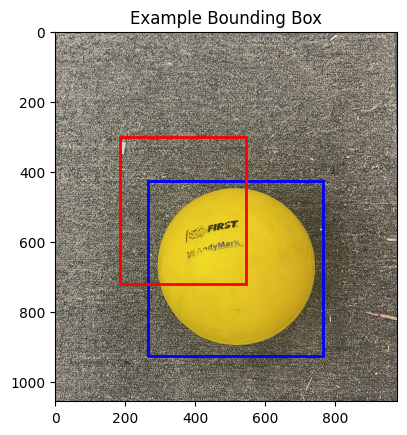

In [91]:
# plot our predicted and ground truth bounding boxes

fig, ax = plt.subplots()
ax.imshow(ball)

# draw ground truth bounding box
ground_box = Rectangle((265,425),500,500,fill=False,linewidth=2, color = 'blue')
ax.add_patch(ground_box)

# draw predicted bounding box
pred_box = Rectangle((187, 300),360,420,fill=False,linewidth=2, color = 'red')
ax.add_patch(pred_box)

ax.set_title("Example Bounding Box")
plt.show()

In [107]:
# finally return our IoU 
print(round(calculate_iou(ground_box, pred_box), 2))

0.26


Unsurprisingly, our predicted box didn't fair so well! 